In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
import time
from multiprocessing import Process
import multiprocessing
from random import randint
from itertools import product
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Parameters
pkt_prob = 0.5
e_prob = 0.5
weight_prob = 0.5

h_vals = [0.1, 1]
h_bad = 0.5
h_prob = [h_bad, (1-h_bad)]
weight_vals = [1, 2]
B_max = 2
rmax = 1
M = 2

B_vals   = np.arange(0, B_max + 1, 1)
rem_vals = np.arange(0, rmax + 0.5, 0.5)

all_states = []
for B in product(B_vals, repeat=M):                 # B1..BM
    for rem in product(rem_vals, repeat=M):         # rem1..remM
        for h in product(h_vals, repeat=M):         # h1..hM
            for w in product(weight_vals, repeat=M):# w1..wM
                state = (*B, *rem, *h, *w)
                all_states.append(state)
all_states = np.array(all_states)
print(all_states.shape)

(1296, 8)


In [7]:
new_state = all_states[:: 10]
print(new_state.shape)

(130, 8)


In [8]:
all_states = new_state

In [ ]:
def st_tr_wt(wt, wt_next):
    if wt == 1 and wt_next == 1:
        m = (1-pkt_prob) + (pkt_prob) * (weight_prob)
    elif wt == 1 and wt_next == 2:
        m = pkt_prob * (1 - weight_prob)
    elif wt == 2 and wt_next == 1:
        m = pkt_prob * weight_prob
    else:
        m = (1-pkt_prob) + pkt_prob * (1-weight_prob)
    return m

In [ ]:
def one_slot_greedy_T_Mu(state):
    B   = state[0:M]
    rem = state[M:2*M]
    h   = state[2*M:3*M]
    wt  = state[3*M:4*M]
    rho = [cp.Variable(nonneg=True) for _ in range(M)]
    P   = [cp.Variable(nonneg=True) for _ in range(M)]
    obj = 0
    for i in range(M):
        obj += wt[i] * cp.exp(-(rmax - (rem[i] - rho[i])))
    log2 = cp.inv_pos(cp.log(2))
    cons = []
    for i in range(M):
        cons += [
            P[i]   <= B[i],
            rho[i] <= rem[i],
            rho[i] <= cp.log(1 + h[i]*P[i]) * log2
            ]
    # --- Full MAC subset constraints ---
    from itertools import combinations
    users = list(range(M))
    for k in range(2, M+1):
        for S in combinations(users, k):
            sum_rho = sum(rho[i] for i in S)
            sum_pow = sum(h[i]*P[i] for i in S)
            cons.append(sum_rho <= cp.log(1 + sum_pow) * log2)
    # --- Solve ---
    prob = cp.Problem(cp.Minimize(obj), cons)
    return prob.solve(verbose=False)

In [ ]:
V = []
for state in all_states:
        V.append(one_slot_greedy_T_Mu(state))
V = np.array(V)
V= np.abs(V)
print(V.shape)

In [ ]:
def quad_fit(all_states, Vy):
    X  = all_states
    y = Vy
    y = y.reshape(-1, 1)
    n = X.shape[1]
    P = cp.Variable((n, n), symmetric=True)
    q = cp.Variable(n)
    r = cp.Variable()
    temp = [cp.quad_form(X[i, :], P) + X[i, :] @ q + r for i in range(X.shape[0])]
    temp = cp.vstack(temp)
    objective = cp.Minimize(cp.sum_squares(temp - y))
    constraints = [P >> 0, temp >= 1e-8]
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS, eps=1e-8)
    P_opt = P.value
    q_opt = q.value
    r_opt = r.value
    def is_positive_semidefinite(matrix):
        # Check if the matrix is symmetric
        if not np.allclose(matrix, matrix.T):
            print("The matrix is not symmetric.")
            return False
        eigenvalues = np.linalg.eigvals(matrix)
        if np.all(eigenvalues >= 0):
            return True
        else:
            print("The matrix has negative eigenvalues:", eigenvalues)
            return False
    flag = 0
    if is_positive_semidefinite(P_opt):
        print("The matrix is positive semidefinite.")
    else:
        print("The matrix is not positive semidefinite.")
        flag = 1
        # print(P_opt)
    return P_opt, q_opt, r_opt, flag

In [ ]:
# import cvxpy as cp
# import numpy as np

# def quad_fit(all_states, Vy):
#     batch_size=100
#     X = all_states
#     y = Vy.reshape(-1, 1)
#     N, n = X.shape
    
#     P = cp.Variable((n, n), symmetric=True)
#     q = cp.Variable((n, 1))
#     r = cp.Variable()
    
#     objective_expr = 0
#     constraints = [P >> 0]
    
#     for k in range(0, N, batch_size):
#         Xb = X[k:k+batch_size]
#         yb = y[k:k+batch_size]
        
#         quad = cp.sum(cp.multiply(Xb @ P, Xb), axis=1, keepdims=True)
#         lin  = Xb @ q
#         preds = quad + lin + r
        
#         objective_expr += cp.sum_squares(preds - yb)
#         constraints.append(preds >= 1e-8)
    
#     prob = cp.Problem(cp.Minimize(objective_expr), constraints)
#     prob.solve(solver=cp.SCS, eps=1e-8)
    
#     P_opt = P.value
#     q_opt = q.value.flatten()
#     r_opt = float(r.value)
    
#     return P_opt, q_opt, r_opt, 0

In [ ]:
def one_slot_greedy_2(state, P_opt, q_opt, r_opt, gamma, send_end):
    B   = state[0:M]
    rem = state[M:2*M]
    h   = state[2*M:3*M]
    wt  = state[3*M:4*M]
    rho = [cp.Variable(nonneg=True) for _ in range(M)]
    P   = [cp.Variable(nonneg=True) for _ in range(M)]
    obj_fn = 0
    for i in range(M):
        obj_fn += wt[i] * cp.exp(-(rmax - (rem[i] - rho[i])))
    ####################################################
    B_end = [B[i] - P[i] for i in range(M)]
    B_ch_arr = [[B_end[i], B_end[i] + 1] for i in range(M)]
    r_ch_arr = [[rem[i] - rho[i], rmax] for i in range(M)]
    wt_ch_arr = [[1, 2] for _ in range(M)]
    all_possible_next_states = []
    for combo in product(*B_ch_arr, *r_ch_arr, *([h_vals]*M), *wt_ch_arr):
        ns = list(combo)
        all_possible_next_states.append(ns)
    #####################################################
    Vz = []
    for next_state in all_possible_next_states:
        ns_vec = cp.hstack(next_state)
        value = cp.quad_form(ns_vec, P_opt) + ns_vec @ q_opt + r_opt
        Vz.append(value)
    Vz = cp.hstack(Vz)
    #############################################
    B_ch_pr = np.array([1 - e_prob, e_prob])
    r_ch_pr = np.array([1 - pkt_prob, pkt_prob])
    wt_ch_pr = []
    for i in range(M):
        if wt[i] == 1:
            wt_ch_pr.append([st_tr_wt(1,1), st_tr_wt(1,2)])
        else:
            wt_ch_pr.append([st_tr_wt(2,1), st_tr_wt(2,2)])
    next_state_prob = []
    for combo in product(*([B_ch_pr]*M), *([r_ch_pr]*M), *([h_prob]*M), *wt_ch_pr):
        pr = 1
        for x in combo:
            pr *= x
        next_state_prob.append(pr)
    next_state_prob = np.array(next_state_prob)
    next_state_prob = cp.hstack(np.array(next_state_prob))
    ####################################################################
    Expected_V = gamma * (Vz @ next_state_prob)
    obj_fn += Expected_V
    constraints = []
    for i in range(M):
        constraints += [
            P[i]   >= 0,
            rho[i] >= 0,
            P[i]   <= B[i],
            rho[i] <= rem[i]
        ]

    log2 = cp.inv_pos(cp.log(2))
    # Single-user MAC bounds
    for i in range(M):
        constraints.append(
            rho[i] <= cp.log(1 + h[i]*P[i]) * log2)
    # Full MAC subset constraints
    from itertools import combinations
    users = list(range(M))
    for k in range(2, M+1):
        for S in combinations(users, k):
            sum_rho = sum(rho[i] for i in S)
            sum_pow = sum(h[i]*P[i] for i in S)
            constraints.append(
                sum_rho <= cp.log(1 + sum_pow) * log2)
    objective = cp.Minimize(obj_fn)
    prob = cp.Problem(objective, constraints)
    optimal_val = prob.solve(verbose=False)
    send_end.send(optimal_val)

In [ ]:
T = 6
stp = 1
import time
while(stp < T):
    t11 = time.time()
    print('stp', stp)
    P_opt, q_opt, r_opt, flag = quad_fit(all_states, V)
    def make_positive_semidefinite(matrix, tolerance=1e-10):
        matrix = (matrix + matrix.T) / 2
        eigenvalues, eigenvectors = np.linalg.eigh(matrix)
        eigenvalues[eigenvalues < tolerance] = 0
        perturbed_matrix = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
        perturbed_matrix = (perturbed_matrix + perturbed_matrix.T) / 2
        return perturbed_matrix
    # Check if the perturbed matrix is PSD
    def is_positive_semidefinite(matrix):
        eigenvalues = np.linalg.eigvals(matrix)
        return np.all(eigenvalues >= 0)    
    if flag == 1:
        psd_matrix = make_positive_semidefinite(P_opt)
        P_opt = psd_matrix
        # print("\nPerturbed matrix:")
        # print(psd_matrix)
        if is_positive_semidefinite(psd_matrix):
            print("\nThe perturbed matrix is positive semidefinite.")
        else:
            print("\nThe perturbed matrix is not positive semidefinite.")
    # policy_run(100,P_opt, q_opt, r_opt)
    psd_matrix = make_positive_semidefinite(P_opt)
    P_opt = psd_matrix
    V_next = np.array([])
    z = 9
    q = 0
    while(z <= len(all_states)):
        t2 = time.time()
        jobs = []
        pipe_list = []
        for state in all_states[q:z]:
            recv_end, send_end = multiprocessing.Pipe(False)
            p = Process(target=one_slot_greedy_2, args=(state, P_opt, q_opt, r_opt, 0.99, send_end))
            jobs.append(p)
            pipe_list.append(recv_end)
        for process in jobs:
            process.start()
        for process in jobs:
            process.join()
        V_next_1 = np.array([x.recv() for x in pipe_list])
        V_next = np.concatenate((V_next, V_next_1))
        q = z
        z+= 9
        if z%81 == 0:
            print('z', z)
        # print(time.time() - t2)
    V_next = np.abs(V_next)
    V  = V_next
    # print(V)
    print('-----------------------')
    print(time.time() - t11)
    stp+= 1
print('value iteration done', pkt_prob, e_prob, weight_prob)

In [ ]:
def one_slot_greedy_33(state, P_opt, q_opt, r_opt, gamma=0.99):
    B   = state[0:M]
    rem = state[M:2*M]
    h   = state[2*M:3*M]
    wt  = state[3*M:4*M]
    rho = [cp.Variable(nonneg=True) for _ in range(M)]
    P   = [cp.Variable(nonneg=True) for _ in range(M)]
    obj_fn = 0
    for i in range(M):
        obj_fn += wt[i] * cp.exp(-(rmax - (rem[i] - rho[i])))
    ####################################################
    B_end = [B[i] - P[i] for i in range(M)]
    B_ch_arr = [[B_end[i], B_end[i] + 1] for i in range(M)]
    r_ch_arr = [[rem[i] - rho[i], rmax] for i in range(M)]
    wt_ch_arr = [[1, 2] for _ in range(M)]
    all_possible_next_states = []
    for combo in product(*B_ch_arr, *r_ch_arr, *([h_vals]*M), *wt_ch_arr):
        ns = list(combo)
        all_possible_next_states.append(ns)
    #####################################################
    Vz = []
    for next_state in all_possible_next_states:
        ns_vec = cp.hstack(next_state)
        value = cp.quad_form(ns_vec, P_opt) + ns_vec @ q_opt + r_opt
        Vz.append(value)
    Vz = cp.hstack(Vz)
    #############################################
    B_ch_pr = np.array([1 - e_prob, e_prob])
    r_ch_pr = np.array([1 - pkt_prob, pkt_prob])
    wt_ch_pr = []
    for i in range(M):
        if wt[i] == 1:
            wt_ch_pr.append([st_tr_wt(1,1), st_tr_wt(1,2)])
        else:
            wt_ch_pr.append([st_tr_wt(2,1), st_tr_wt(2,2)])
    next_state_prob = []
    for combo in product(*([B_ch_pr]*M), *([r_ch_pr]*M), *([h_prob]*M), *wt_ch_pr):
        pr = 1
        for x in combo:
            pr *= x
        next_state_prob.append(pr)
    next_state_prob = np.array(next_state_prob)
    next_state_prob = cp.hstack(np.array(next_state_prob))
    ####################################################################
    Expected_V = gamma * (Vz @ next_state_prob)
    obj_fn += Expected_V
    constraints = []
    for i in range(M):
        constraints += [
            P[i]   >= 0,
            rho[i] >= 0,
            P[i]   <= B[i],
            rho[i] <= rem[i] ]
    log2 = cp.inv_pos(cp.log(2))
    # Single-user bounds
    for i in range(M):
        constraints.append(
            rho[i] <= cp.log(1 + h[i]*P[i]) * log2 )
    # Full MAC region (all subsets)
    from itertools import combinations
    users = list(range(M))
    for k in range(2, M+1):
        for S in combinations(users, k):
            sum_rho = sum(rho[i] for i in S)
            sum_pow = sum(h[i]*P[i] for i in S)
            constraints.append(
                sum_rho <= cp.log(1 + sum_pow) * log2)
    objective = cp.Minimize(obj_fn)
    prob = cp.Problem(objective, constraints)
    optimal_val = prob.solve(verbose=False)
    P_val   = [Pi.value for Pi in P]
    rho_val = [ri.value for ri in rho]
    return P_val, rho_val, optimal_val

In [ ]:
def policy_run(T_horizon, P_opt, q_opt, r_opt):
    tot_dist = 0
    B_prev  = np.ones(M)      # initial battery
    rem_prev = np.zeros(M)    # initial remaining bits
    wt_prev  = np.ones(M)     # initial weights
    for t in range(T_horizon):
        wt_rand  = np.random.choice([1,2], size=M, p=[weight_prob, 1-weight_prob])
        h_rand   = np.random.choice([0.1,1], size=M, p=h_prob)
        pkt_rand = np.random.choice([1,0], size=M, p=[pkt_prob, 1-pkt_prob])
        E_rand   = np.random.choice([1,0], size=M, p=[e_prob, 1-e_prob])

        rem_start = np.zeros(M)
        wt_start  = np.zeros(M)
        for i in range(M):
            if pkt_rand[i] == 1:
                wt_start[i]  = wt_rand[i]
                rem_start[i] = rmax
            else:
                wt_start[i]  = wt_prev[i]
                rem_start[i] = rem_prev[i]
        B_start = np.minimum(B_prev + E_rand, B_max)
        state_slot = np.concatenate([B_start, rem_start, h_rand, wt_start])

        P_val, rho_val, VT = one_slot_greedy_33(state_slot, P_opt, q_opt, r_opt, 0.99)
        P_val   = np.array(P_val)
        rho_val = np.array(rho_val)
        B_prev  = np.maximum(B_start - P_val, 0)
        rem_prev = np.maximum(rem_start - rho_val, 0)
        wt_prev  = wt_start.copy()
        dist = 0
        for i in range(M):
            dist += wt_start[i] * np.exp(-(rmax - rem_prev[i]))
        tot_dist += dist
        if t % 100 == 0:
            print('obj', t, tot_dist/((t+1)))

In [ ]:
policy_run(1001,P_opt, q_opt, r_opt)

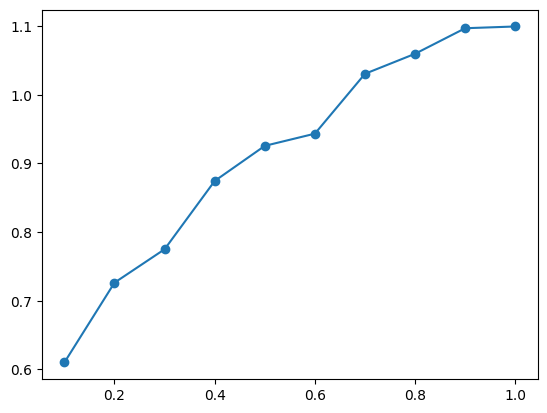

In [46]:
import matplotlib.pyplot as plt
import numpy as np

lambda_arr = np.arange(0.1, 1.1, 0.1)

res = np.array([1.2202, 1.4526, 1.5500, 1.7489, 1.8512, 1.8867, 2.0611, 2.1194, 2.1938, 2.1989])



plt.plot(lambda_arr, res/2, 'o-')
plt.show()